In [63]:
import matplotlib.pyplot as plt
import numpy as np

In [64]:
plt.style.use("dark_background")
plt.rcParams["figure.figsize"] = (10, 8)

In [65]:
def get_linear_curve(x, w: float, b: float = 0, noise_scale: float = 0):
    return w * x + b + noise_scale * np.random.randn(x.shape[0])

In [66]:
x = np.arange(-10, 30.1, 0.5)
y = get_linear_curve(x, 1.8, 32, noise_scale=10)

In [67]:
x.shape, y.shape

((81,), (81,))

Text(0, 0.5, '°C')

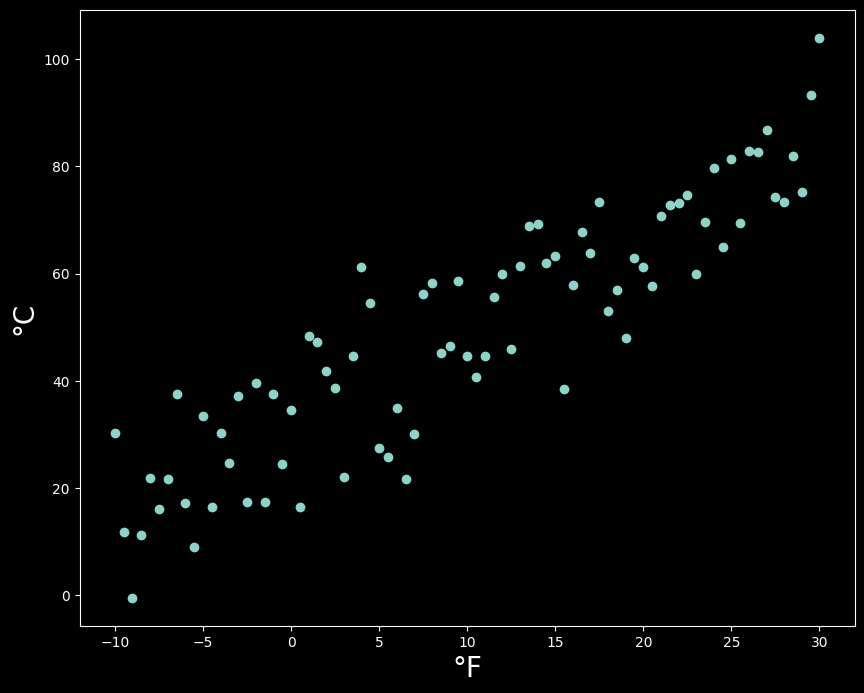

In [68]:
plt.scatter(x, y)
plt.xlabel('°F', fontsize=20)
plt.ylabel('°C', fontsize=20)

(array([4.000000e+00, 2.200000e+01, 1.150000e+02, 4.040000e+02,
        1.598000e+03, 5.561000e+03, 1.591000e+04, 4.176000e+04,
        9.790800e+04, 2.035620e+05, 3.747310e+05, 6.145930e+05,
        8.923060e+05, 1.157031e+06, 1.330373e+06, 1.359076e+06,
        1.238347e+06, 9.994090e+05, 7.189200e+05, 4.599640e+05,
        2.620410e+05, 1.316210e+05, 5.907400e+04, 2.358900e+04,
        8.384000e+03, 2.663000e+03, 7.890000e+02, 2.000000e+02,
        3.600000e+01, 9.000000e+00]),
 array([-5.23512606, -4.89050582, -4.54588557, -4.20126533, -3.85664508,
        -3.51202484, -3.16740459, -2.82278435, -2.4781641 , -2.13354386,
        -1.78892361, -1.44430337, -1.09968312, -0.75506288, -0.41044263,
        -0.06582239,  0.27879786,  0.6234181 ,  0.96803835,  1.3126586 ,
         1.65727884,  2.00189909,  2.34651933,  2.69113958,  3.03575982,
         3.38038007,  3.72500031,  4.06962056,  4.4142408 ,  4.75886105,
         5.10348129]),
 <BarContainer object of 30 artists>)

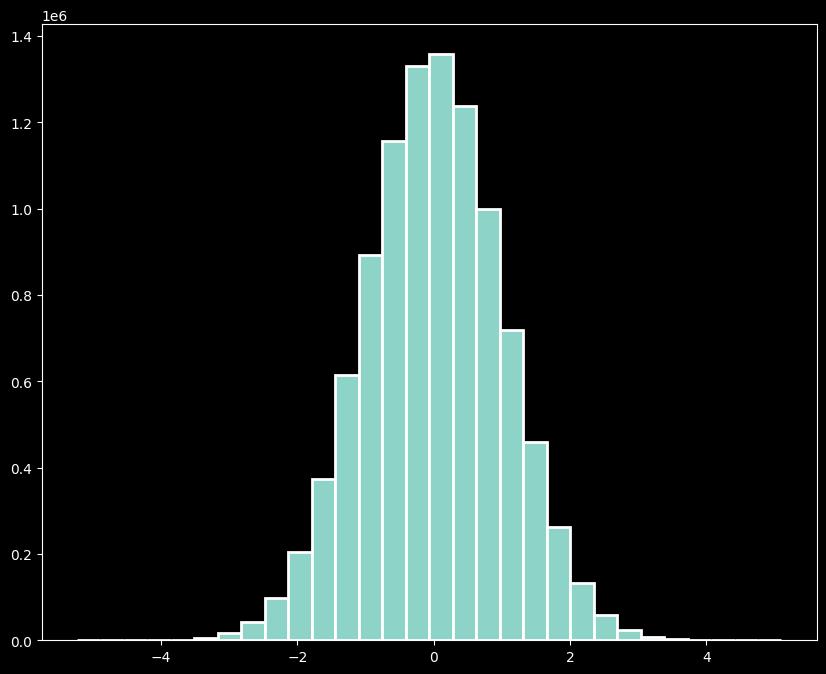

In [69]:
plt.hist(np.random.randn(10000000), bins=30, edgecolor="white", linewidth=2)

# Modelo
- Inicializar os pesos em bias
- Feedforward
- Calular a perda
- Backpropagation


In [70]:
# inicializar

peso = np.random.rand(1)
b = 0

In [71]:
def forward(inputs, w, b):
    return w * inputs + b

In [72]:
def mse(valor_real: np.ndarray, previsao: np.ndarray):
    return (valor_real - previsao) ** 2

In [73]:
def backpropagation(inputs: np.ndarray, outputs: np.ndarray, targets: np.ndarray, learning_rate: float, w, b):
    novo_peso = learning_rate * (-2 * inputs * (targets - outputs)).mean()
    novo_b = learning_rate * (-2 * (targets - outputs)).mean()

    w -= novo_peso
    b -= novo_b
    return w, b

In [74]:
def model_fit(inputs, target, w, b, epochs=200, learning_rate=0.001):
    for epoch in range(epochs):
        output = forward(inputs, w, b)
        loss = np.mean(mse(output, target))
        w, b = backpropagation(inputs, output, target, learning_rate, w, b)

        if (epoch + 1) % 50 == 0:
            print(f'epoch: [{(epoch + 1)} / {epochs}] loss: {loss:.4f}')
    return w, b

In [75]:
# inicialização
x = np.arange(-10, 10, 2)
y = get_linear_curve(x, w=1.8, b=32, noise_scale=2.5)

w = np.random.randn(1)
b = np.zeros(1)

# Treinando modelo
w, b = model_fit(x, y, w, b, epochs=1000, learning_rate=0.029)
print(f'w: {w[0]:.3f}, b: {b[0]:.3f}')

epoch: [50 / 1000] loss: 6.1558
epoch: [100 / 1000] loss: 2.4401
epoch: [150 / 1000] loss: 2.3968
epoch: [200 / 1000] loss: 2.3945
epoch: [250 / 1000] loss: 2.3943
epoch: [300 / 1000] loss: 2.3943
epoch: [350 / 1000] loss: 2.3943
epoch: [400 / 1000] loss: 2.3943
epoch: [450 / 1000] loss: 2.3943
epoch: [500 / 1000] loss: 2.3943
epoch: [550 / 1000] loss: 2.3943
epoch: [600 / 1000] loss: 2.3943
epoch: [650 / 1000] loss: 2.3943
epoch: [700 / 1000] loss: 2.3943
epoch: [750 / 1000] loss: 2.3943
epoch: [800 / 1000] loss: 2.3943
epoch: [850 / 1000] loss: 2.3943
epoch: [900 / 1000] loss: 2.3943
epoch: [950 / 1000] loss: 2.3943
epoch: [1000 / 1000] loss: 2.3943
w: 1.762, b: 31.217


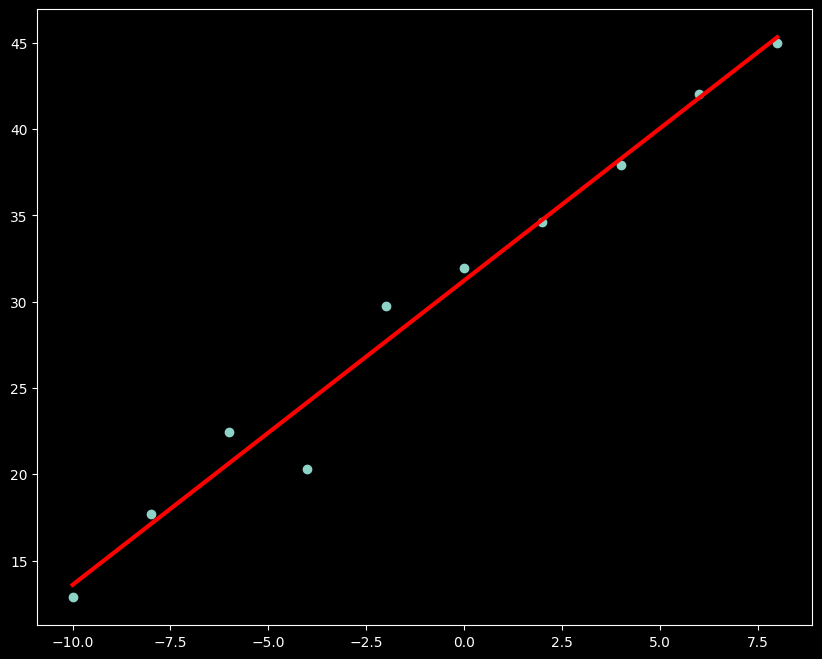

In [76]:
plt.scatter(x, y)
plt.plot(x, get_linear_curve(x, w, b), 'r', lw=3)